In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from feature_eng_functions import drop_unnecessary, occupation_mapping, summarize_workclass
from sklearn.svm import SVC
from sklearn.compose import ColumnTransformer, make_column_transformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay, classification_report, accuracy_score, precision_score, recall_score, f1_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

from imblearn.under_sampling import RandomUnderSampler

In [2]:
base_adult = pd.read_csv(filepath_or_buffer="adult\\adult.data")
base_adult

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [3]:
base_adult.drop(base_adult.loc[base_adult.workclass == " ?"].index, inplace=True)

In [4]:
base_adult.drop(base_adult.loc[base_adult.occupation == " ?"].index, inplace=True)

In [5]:
base_adult["occupation"] = base_adult["occupation"].apply(func=occupation_mapping)
base_adult

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Office-Worker,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Office-Worker,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Manual-Worker,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Manual-Worker,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Office-Worker,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Office-Worker,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machinery-Worker,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Office-Worker,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Office-Worker,Own-child,White,Male,0,0,20,United-States,<=50K


In [6]:
#base_adult["workclass"] = base_adult["workclass"].apply(func=summarize_workclass)

In [7]:
base_adult = drop_unnecessary(df=base_adult)
base_adult

,age,workclass,fnlwgt,education-num,occupation,income
0,39,State-gov,77516,13,Office-Worker,<=50K
1,50,Self-emp-not-inc,83311,13,Office-Worker,<=50K
2,38,Private,215646,9,Manual-Worker,<=50K
3,53,Private,234721,7,Manual-Worker,<=50K
4,28,Private,338409,13,Office-Worker,<=50K
...,...,...,...,...,...,...
32556,27,Private,257302,12,Office-Worker,<=50K
32557,40,Private,154374,9,Machinery-Worker,>50K
32558,58,Private,151910,9,Office-Worker,<=50K
32559,22,Private,201490,9,Office-Worker,<=50K


In [8]:
base_adult["occupation"].map(lambda x: str.strip(x))
base_adult["occupation"][0]

'Office-Worker'

In [9]:
X = base_adult.drop(columns=["income"])
y = base_adult["income"]

In [10]:
#income_replacer = {" <=50K": 0, " >50K": 1}
#y.replace(income_replacer, inplace=True)

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)
X_train

,age,workclass,fnlwgt,education-num,occupation
29003,27,Private,165519,9,Machinery-Worker
22291,35,Private,188972,9,Office-Worker
23927,27,Private,491421,3,Manual-Worker
27653,38,Private,103925,9,Office-Worker
1160,44,Private,193459,11,Machinery-Worker
...,...,...,...,...,...
5683,41,Private,163322,13,Office-Worker
26618,62,Self-emp-not-inc,226546,15,Office-Worker
17786,37,Private,219546,11,Machinery-Worker
12310,22,Private,166371,10,Machinery-Worker


In [12]:
X_train, y_train = RandomUnderSampler().fit_resample(X_train, y_train)

In [13]:
cat_variables = ["workclass", "occupation"]
num_variables = ["age", "fnlwgt", "education-num"]

In [14]:
column_tranform = make_column_transformer(
    (StandardScaler(), num_variables),
    (OneHotEncoder(), cat_variables)
)

In [15]:
knn = KNeighborsClassifier()
knn_pipe = Pipeline(steps=[("colum_transforms", column_tranform), ("knn", knn)])

In [16]:
param_grid = {
    "knn__n_neighbors": [3, 5],
    "knn__weights": ["uniform", "distance"],
    "knn__algorithm": ["ball_tree", "kd_tree", "brute"],
    "knn__p": [1, 2]
}
knn_grid = GridSearchCV(knn_pipe, param_grid, cv=5, scoring='accuracy')

In [17]:
knn_grid.fit(X_train, y_train)
knn_grid.best_params_

c:\Users\gustavo.o.gois\OneDrive - Accenture\Documents\GitHub\Adults\.venv\Lib\site-packages\sklearn\model_selection\_validation.py:927: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "c:\Users\gustavo.o.gois\OneDrive - Accenture\Documents\GitHub\Adults\.venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 916, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
  File "c:\Users\gustavo.o.gois\OneDrive - Accenture\Documents\GitHub\Adults\.venv\Lib\site-packages\sklearn\metrics\_scorer.py", line 317, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\gustavo.o.gois\OneDrive - Accenture\Documents\GitHub\Adults\.venv\Lib\site-packages\sklearn\metrics\_scorer.py", line 409, in _score
    y_pred =

{'knn__algorithm': 'ball_tree',
 'knn__n_neighbors': 5,
 'knn__p': 2,
 'knn__weights': 'uniform'}

In [18]:
scores_knn = cross_val_score(knn_grid, X_test, y_test, cv=5, scoring="accuracy")
scores_knn

c:\Users\gustavo.o.gois\OneDrive - Accenture\Documents\GitHub\Adults\.venv\Lib\site-packages\sklearn\model_selection\_validation.py:927: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "c:\Users\gustavo.o.gois\OneDrive - Accenture\Documents\GitHub\Adults\.venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 916, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
  File "c:\Users\gustavo.o.gois\OneDrive - Accenture\Documents\GitHub\Adults\.venv\Lib\site-packages\sklearn\metrics\_scorer.py", line 317, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\gustavo.o.gois\OneDrive - Accenture\Documents\GitHub\Adults\.venv\Lib\site-packages\sklearn\metrics\_scorer.py", line 409, in _score
    y_pred =

array([0.74043938, 0.76240846, 0.77786819, 0.75508544, 0.75081433])

In [19]:
rf_clf = DecisionTreeClassifier(class_weight="balanced")
rf_pipe = Pipeline(steps=[("colum_transforms", column_tranform), ("rf_clf", rf_clf)])

In [20]:
param_grid = {
    "rf_clf__criterion": ["gini", "entropy", "log_loss"],
    "rf_clf__splitter": ["random", "best"]
}

fr_grid = GridSearchCV(rf_pipe, param_grid, cv=5, scoring='accuracy')

In [21]:
fr_grid.fit(X_train, y_train)
fr_grid.best_params_

{'rf_clf__criterion': 'entropy', 'rf_clf__splitter': 'random'}

In [22]:
scores_rf = cross_val_score(fr_grid, X_test, y_test, cv=5, scoring="accuracy")
scores_rf

c:\Users\gustavo.o.gois\OneDrive - Accenture\Documents\GitHub\Adults\.venv\Lib\site-packages\sklearn\model_selection\_validation.py:927: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "c:\Users\gustavo.o.gois\OneDrive - Accenture\Documents\GitHub\Adults\.venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 916, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
  File "c:\Users\gustavo.o.gois\OneDrive - Accenture\Documents\GitHub\Adults\.venv\Lib\site-packages\sklearn\metrics\_scorer.py", line 317, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\gustavo.o.gois\OneDrive - Accenture\Documents\GitHub\Adults\.venv\Lib\site-packages\sklearn\metrics\_scorer.py", line 409, in _score
    y_pred =

array([0.70463792, 0.71277461, 0.72172498, 0.71114727, 0.72557003])

In [23]:
logistic_reg = LogisticRegression(class_weight="balanced")

logistic_pipe = Pipeline(steps=[
    ("colum_transform", column_tranform),
    ("logistic_reg", logistic_reg)
])

In [24]:
param_grid = {
    "logistic_reg__l1_ratio": [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
}

logistic_grid = GridSearchCV(logistic_pipe, param_grid, cv=5, scoring="accuracy")
logistic_grid.fit(X=X_train, y=y_train)

c:\Users\gustavo.o.gois\OneDrive - Accenture\Documents\GitHub\Adults\.venv\Lib\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
50 fits failed out of a total of 55.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
45 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\gustavo.o.gois\OneDrive - Accenture\Documents\GitHub\Adults\.venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\gustavo.o.gois\OneDrive - Accenture\Documents\GitHub\Adults\.venv\Lib\site-packages\sklearn\base.py", line 1336, in wrapper
    return fit_meth

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...'balanced'))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'logistic_reg__l1_ratio': [0.0, 0.1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fo

In [25]:
logistic_score = cross_val_score(logistic_grid, X_test, y_test, scoring="accuracy")
logistic_score

c:\Users\gustavo.o.gois\OneDrive - Accenture\Documents\GitHub\Adults\.venv\Lib\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
50 fits failed out of a total of 55.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
45 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\gustavo.o.gois\OneDrive - Accenture\Documents\GitHub\Adults\.venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\gustavo.o.gois\OneDrive - Accenture\Documents\GitHub\Adults\.venv\Lib\site-packages\sklearn\base.py", line 1336, in wrapper
    return fit_meth

array([0.68917819, 0.68185517, 0.69650122, 0.71358828, 0.70765472])

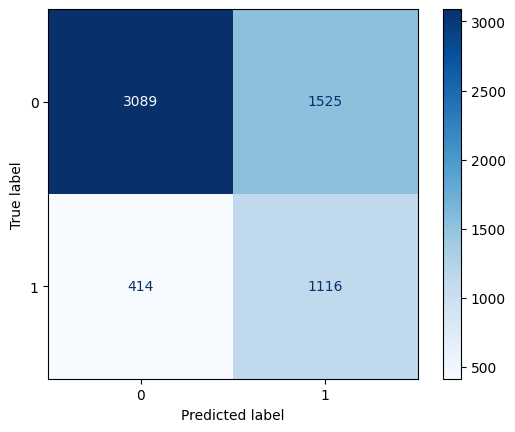

In [27]:
knn_disp = ConfusionMatrixDisplay.from_estimator(
    estimator=knn_grid,
    X=X_test,
    y=y_test,
    display_labels=[0, 1],
    cmap=plt.cm.Blues
)

plt.show()

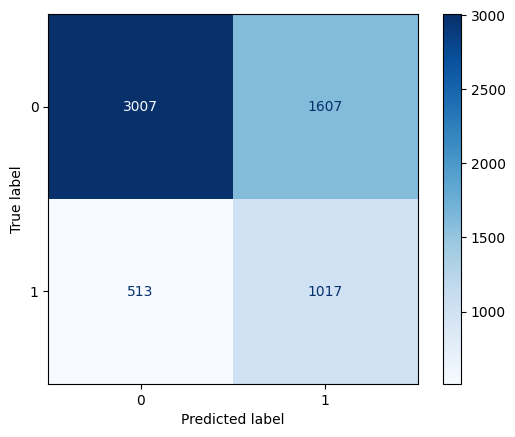

In [28]:
dt_disp = ConfusionMatrixDisplay.from_estimator(
    estimator=fr_grid,
    X=X_test,
    y=y_test,
    display_labels=[0, 1],
    cmap=plt.cm.Blues
)

plt.show()

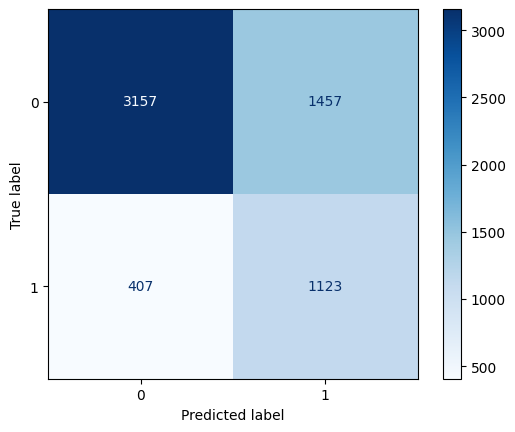

In [29]:
logistic_disp = ConfusionMatrixDisplay.from_estimator(
    estimator=logistic_grid,
    X=X_test,
    y=y_test,
    display_labels=[0, 1],
    cmap=plt.cm.Blues
)

plt.show()

In [30]:
y_pred_knn = knn_grid.predict(X_test)
print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

       <=50K       0.88      0.67      0.76      4614
        >50K       0.42      0.73      0.54      1530

    accuracy                           0.68      6144
   macro avg       0.65      0.70      0.65      6144
weighted avg       0.77      0.68      0.70      6144



In [31]:
accuracy_score(y_test, y_pred_knn)

0.6844075520833334

In [32]:
precision_score(y_test, y_pred_knn, pos_label=" >50K")

0.42256720939038245

In [33]:
recall_score(y_test, y_pred_knn, pos_label=" >50K")

0.7294117647058823

In [34]:
f1_score(y_test, y_pred_knn, pos_label=" >50K")

0.5351234715895469

In [35]:
y_pred_dt = fr_grid.predict(X_test)
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

       <=50K       0.85      0.65      0.74      4614
        >50K       0.39      0.66      0.49      1530

    accuracy                           0.65      6144
   macro avg       0.62      0.66      0.61      6144
weighted avg       0.74      0.65      0.68      6144



In [36]:
accuracy_score(y_test, y_pred_dt)

0.6549479166666666

In [37]:
precision_score(y_test, y_pred_dt, pos_label=" >50K")

0.3875762195121951

In [38]:
recall_score(y_test, y_pred_dt, pos_label=" >50K")

0.6647058823529411

In [39]:
f1_score(y_test, y_pred_dt, pos_label=" >50K")

0.48964853153586907

In [40]:
y_pred_logistic = logistic_grid.predict(X_test)
print(classification_report(y_test, y_pred_logistic))

              precision    recall  f1-score   support

       <=50K       0.89      0.68      0.77      4614
        >50K       0.44      0.73      0.55      1530

    accuracy                           0.70      6144
   macro avg       0.66      0.71      0.66      6144
weighted avg       0.77      0.70      0.72      6144



In [41]:
accuracy_score(y_test, y_pred_logistic)

0.6966145833333334

In [42]:
precision_score(y_test, y_pred_logistic, pos_label=" >50K")

0.4352713178294574

In [43]:
recall_score(y_test, y_pred_logistic, pos_label=" >50K")

0.7339869281045751

In [44]:
f1_score(y_test, y_pred_logistic, pos_label=" >50K")

0.5464720194647202